# E-commerce Sales Analysis

Exploratory data analysis of e-commerce sales using Python and pandas.

## Project Objective

The goal of this project is to analyze e-commerce sales data
and identify patterns in product performance, revenue, sales volume,
and daily sales activity.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("visualizations", exist_ok=True)

In [21]:
data = {
    "Order_ID": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "Date": [
        "2026-01-03", "2026-01-03", "2026-01-04", "2026-01-05",
        "2026-01-05", "2026-01-06", "2026-01-07", "2026-01-07",
        "2026-01-08", "2026-01-09"
    ],
    "Product": [
        "Laptop", "Mouse", "Keyboard", "Laptop", "Monitor",
        "Mouse", "Keyboard", "Laptop", "Monitor", "Mouse"
    ],
    "Category": [
        "Electronics", "Accessories", "Accessories", "Electronics",
        "Electronics", "Accessories", "Accessories", "Electronics",
        "Electronics", "Accessories"
    ],
    "Quantity": [1, 2, 1, 1, 2, 3, 2, 1, 1, 2],
    "Unit_Price": [900, 25, 45, 900, 250, 25, 45, 900, 250, 25]
}

df = pd.DataFrame(data)

df["Revenue"] = df["Quantity"] * df["Unit_Price"]

df.to_csv("sales.csv", index=False)

print("Το dataset δημιουργήθηκε επιτυχώς!")

Το dataset δημιουργήθηκε επιτυχώς!


## 1. Data Overview

First, we inspect the structure and basic characteristics of the dataset.

In [22]:
df.head()

,Order_ID,Date,Product,Category,Quantity,Unit_Price,Revenue
0,1001,2026-01-03,Laptop,Electronics,1,900,900
1,1002,2026-01-03,Mouse,Accessories,2,25,50
2,1003,2026-01-04,Keyboard,Accessories,1,45,45
3,1004,2026-01-05,Laptop,Electronics,1,900,900
4,1005,2026-01-05,Monitor,Electronics,2,250,500


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Order_ID    10 non-null     int64 
 1   Date        10 non-null     object
 2   Product     10 non-null     object
 3   Category    10 non-null     object
 4   Quantity    10 non-null     int64 
 5   Unit_Price  10 non-null     int64 
 6   Revenue     10 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 692.0+ bytes


## 2. Data Cleaning

The Date column is converted to datetime format.
We also check for missing values and duplicate rows.

In [24]:
df["Date"] = pd.to_datetime(df["Date"])

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Order_ID      0
Date          0
Product       0
Category      0
Quantity      0
Unit_Price    0
Revenue       0
dtype: int64

Duplicate rows:
0


## 3. Sales Analysis

In [25]:
total_revenue = df["Revenue"].sum()
print("Total revenue:", total_revenue, "€")

Total revenue: 3760 €


In [26]:
total_quantity = df["Quantity"].sum()
print("Total units sold:", total_quantity)

Total units sold: 16


In [27]:
average_unit_price = df["Unit_Price"].mean()
print("Average unit price:", average_unit_price, "€")

Average unit price: 336.5 €


## 4. Product Analysis

In [28]:
revenue_by_product = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_product

,Revenue
Product,
Laptop,2700
Monitor,750
Mouse,175
Keyboard,135


In [29]:
quantity_by_product = (
    df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

quantity_by_product

,Quantity
Product,
Mouse,7
Keyboard,3
Laptop,3
Monitor,3


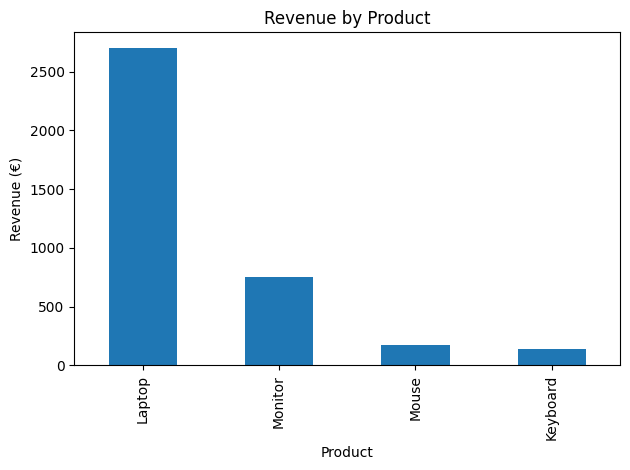

In [30]:
revenue_by_product.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (€)")

plt.tight_layout()
plt.savefig("visualizations/revenue_by_product.png")

plt.show()

## 5. Sales Over Time

In [31]:
daily_revenue = df.groupby("Date")["Revenue"].sum()

daily_revenue

,Revenue
Date,
2026-01-03,950
2026-01-04,45
2026-01-05,1400
2026-01-06,75
2026-01-07,990
2026-01-08,250
2026-01-09,50


In [32]:
best_day = daily_revenue.idxmax()
best_day_revenue = daily_revenue.max()

print("Best sales day:", best_day)
print("Revenue:", best_day_revenue, "€")

Best sales day: 2026-01-05 00:00:00
Revenue: 1400 €


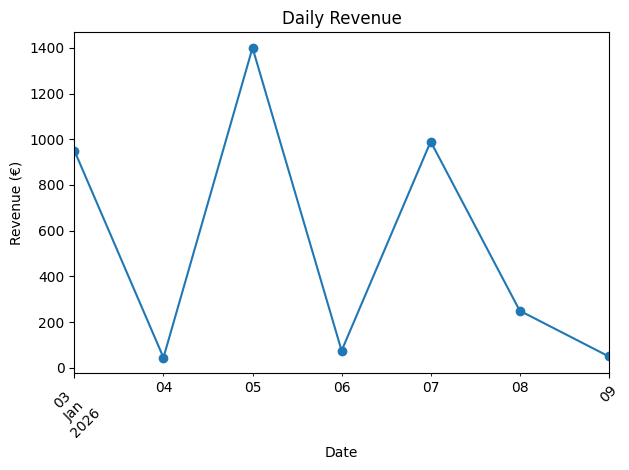

In [33]:
daily_revenue.plot(kind="line", marker="o")

plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (€)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("visualizations/daily_revenue.png")

plt.show()

## 6. Key Findings

- Laptop generated the highest revenue among the products.
- Mouse had the highest number of units sold.
- January 5 was the strongest sales day by revenue.
- Electronics accounted for the majority of total revenue.
- The product with the highest sales volume was not the product generating the highest revenue.

In [34]:
import os

os.makedirs("data", exist_ok=True)

In [35]:
df.to_csv("data/sales.csv", index=False)

In [37]:

from google.colab import files
files.download("data/sales.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>